# Dawood — Ullah 2022 XGBoost

In [1]:
MODEL_ID="Dawood_Ullah2022_XGBoost"
MODEL_NAME="Dawood_XGBoost_Ullah2022"

%pip -q install pandas numpy matplotlib seaborn scikit-learn shap lime xgboost catboost tensorflow joblib

import os, warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

if not hasattr(np, "bool"):
    np.bool = np.bool_
if not hasattr(np, "int"):
    np.int = int

try:
    from google.colab import drive
    drive.mount("/content/drive")
except Exception as e:
    print("Drive mount skipped:", e)

from sklearn.model_selection import train_test_split, learning_curve
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_curve, average_precision_score
)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler, QuantileTransformer
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

import shap
from lime.lime_tabular import LimeTabularExplainer

sns.set(style="whitegrid")
RANDOM_STATE = 42
TARGET = "Diabetes"

def find_data_dir():
    candidates = [
        Path("/content/drive/MyDrive/BRFSS2015_processed"),
        Path("BRFSS2015_processed"),
        Path("artifacts"),
        Path(".")
    ]
    for d in candidates:
        if (d/"train.csv").exists() and (d/"test.csv").exists():
            return d
    raise FileNotFoundError("Cannot find train.csv and test.csv. Put them in /content/drive/MyDrive/BRFSS2015_processed/")

DATA_DIR = find_data_dir()
OUTPUT_DIR = DATA_DIR / "final_model_outputs_high_accuracy" / MODEL_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Using DATA_DIR:", DATA_DIR)
print("Saving OUTPUT_DIR:", OUTPUT_DIR)

train_df = pd.read_csv(DATA_DIR/"train.csv")
test_df = pd.read_csv(DATA_DIR/"test.csv")
train_df = train_df.loc[:, ~train_df.columns.str.contains("^Unnamed")]
test_df = test_df.loc[:, ~test_df.columns.str.contains("^Unnamed")]

for c in train_df.columns:
    train_df[c] = pd.to_numeric(train_df[c], errors="coerce")
for c in test_df.columns:
    test_df[c] = pd.to_numeric(test_df[c], errors="coerce")

train_df = train_df.fillna(train_df.median(numeric_only=True))
test_df = test_df.fillna(train_df.median(numeric_only=True))

X_train_full = train_df.drop(columns=[TARGET])
y_train_full = train_df[TARGET].astype(int)
X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET].astype(int)
X_test = X_test[X_train_full.columns]

X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full,
    test_size=0.15,
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

feature_cols = list(X_train.columns)
classes = sorted(y_train_full.unique().tolist())
CLASS_NAMES = ["No Diabetes", "Prediabetes", "Diabetes"] if classes == [0,1,2] else [f"Class {c}" for c in classes]

sample_weight_train = compute_sample_weight(class_weight="balanced", y=y_train)
class_weight_values = compute_class_weight(class_weight="balanced", classes=np.array(classes), y=y_train)
CLASS_WEIGHT_DICT = {int(c): float(w) for c, w in zip(classes, class_weight_values)}

print("Train:", X_train.shape, "Val:", X_val.shape, "Test:", X_test.shape)
print("Class weights:", CLASS_WEIGHT_DICT)
display(y_train.value_counts().sort_index().to_frame("train_count"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 23.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 27.4 MB/s eta 0:00:00
Mounted at /content/drive
Using DATA_DIR: /content/drive/MyDrive/BRFSS2015_processed
Saving OUTPUT_DIR: /content/drive/MyDrive/BRFSS2015_processed/final_model_outputs_high_accuracy/Dawood_Ullah2022_XGBoost
Train: (170046, 20) Val: (30009, 20) Test: (50014, 20)
Class weights: {0: 0.4003588128098998, 1: 12.640945584299732, 2: 2.3633255503669113}


,train_count
Diabetes,
0,141578
1,4484
2,23984


In [2]:
def predict_with_threshold(y_prob, diabetes_threshold=None):
    y_pred = np.asarray(y_prob).argmax(axis=1)
    if diabetes_threshold is not None and y_prob.shape[1] >= 3:
        y_pred = y_pred.copy()
        y_pred[y_prob[:,2] >= diabetes_threshold] = 2
    return y_pred

def evaluate(y_true, y_prob, threshold=None):
    y_pred = predict_with_threshold(y_prob, threshold)
    out = {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "diabetes_recall": recall_score((np.asarray(y_true)==2).astype(int), (np.asarray(y_pred)==2).astype(int), zero_division=0),
        "diabetes_precision": precision_score((np.asarray(y_true)==2).astype(int), (np.asarray(y_pred)==2).astype(int), zero_division=0),
    }
    try:
        out["roc_auc_weighted"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="weighted")
        out["roc_auc_macro"] = roc_auc_score(y_true, y_prob, multi_class="ovr", average="macro")
    except Exception:
        out["roc_auc_weighted"] = np.nan
        out["roc_auc_macro"] = np.nan
    return out

def choose_safe_threshold(y_true, y_prob):
    # Very conservative threshold tuning:
    # do not allow accuracy to drop more than 1.5 percentage points from default.
    default = evaluate(y_true, y_prob, None)
    best = {"threshold": None, "score": default["weighted_f1"], **default}
    for t in np.linspace(0.18, 0.50, 17):
        m = evaluate(y_true, y_prob, float(t))
        if m["accuracy"] >= default["accuracy"] - 0.015:
            score = 0.70*m["weighted_f1"] + 0.30*m["diabetes_recall"]
            if score > best["score"]:
                best = {"threshold": float(t), "score": score, **m}
    return best

def show_results(model, model_name, threshold_tuning=True):
    val_prob = model.predict_proba(X_val)
    test_prob = model.predict_proba(X_test)

    safe = choose_safe_threshold(y_val, val_prob) if threshold_tuning else {"threshold": None}
    threshold = safe["threshold"]
    print("Safe threshold selected:", threshold)
    if threshold is not None:
        display(pd.DataFrame([safe]))

    rows = []
    rows.append({"model": model_name, "split": "validation_default", "threshold": None, **evaluate(y_val, val_prob)})
    rows.append({"model": model_name, "split": "test_default_HIGH_ACCURACY", "threshold": None, **evaluate(y_test, test_prob)})
    rows.append({"model": model_name, "split": "validation_safe_threshold", "threshold": threshold, **evaluate(y_val, val_prob, threshold)})
    rows.append({"model": model_name, "split": "test_safe_threshold", "threshold": threshold, **evaluate(y_test, test_prob, threshold)})
    metrics = pd.DataFrame(rows)
    display(metrics)
    metrics.to_csv(OUTPUT_DIR / f"{model_name}_metrics.csv", index=False)

    for label, th in [("default_HIGH_ACCURACY", None), ("safe_threshold", threshold)]:
        y_pred = predict_with_threshold(test_prob, th)
        print("\\n", model_name, label)
        print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, zero_division=0, digits=4))
        disp = ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=CLASS_NAMES)
        disp.plot(cmap="Blues", xticks_rotation=20)
        plt.title(f"{model_name} - {label}")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{model_name}_{label}_confusion.png", dpi=200, bbox_inches="tight")
        plt.show()

    return metrics, threshold

def plot_roc_pr(model, model_name):
    y_prob = model.predict_proba(X_test)
    plt.figure(figsize=(8,6))
    for i, c in enumerate(classes):
        yb = (y_test==c).astype(int)
        fpr,tpr,_ = roc_curve(yb, y_prob[:,i])
        plt.plot(fpr,tpr,label=f"{CLASS_NAMES[i]} AUC={auc(fpr,tpr):.3f}")
    plt.plot([0,1],[0,1],"--",color="gray")
    plt.title(f"{model_name} ROC")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model_name}_roc.png", dpi=200, bbox_inches="tight")
    plt.show()

def run_xai(model, model_name):
    # 1 PFI
    try:
        pfi = permutation_importance(model, X_test, y_test, scoring="roc_auc_ovr_weighted", n_repeats=3, random_state=RANDOM_STATE, n_jobs=-1)
        pfi_df = pd.DataFrame({"feature": feature_cols, "importance": pfi.importances_mean}).sort_values("importance", ascending=False)
        display(pfi_df.head(15))
        pfi_df.to_csv(OUTPUT_DIR / f"{model_name}_pfi.csv", index=False)
        plt.figure(figsize=(8,6))
        sns.barplot(data=pfi_df.head(12), x="importance", y="feature", orient="h")
        plt.title(f"{model_name} PFI")
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{model_name}_pfi.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("PFI failed:", e)

    # 2 PDP and 3 ICE
    feats = [f for f in ["BMI","Age","GenHlth","HighBP"] if f in X_test.columns] or feature_cols[:4]
    small = X_test.sample(min(1000,len(X_test)), random_state=RANDOM_STATE)
    try:
        PartialDependenceDisplay.from_estimator(model, small, feats, target=2, kind="average", grid_resolution=20)
        plt.suptitle(f"{model_name} PDP", y=1.02)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{model_name}_pdp.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("PDP failed:", e)
    try:
        PartialDependenceDisplay.from_estimator(model, small, feats[:2], target=2, kind="individual", subsample=40, grid_resolution=15, random_state=RANDOM_STATE)
        plt.suptitle(f"{model_name} ICE", y=1.02)
        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / f"{model_name}_ice.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("ICE failed:", e)

    # 4 SHAP
    try:
        bg = shap.sample(X_train, min(40,len(X_train)), random_state=RANDOM_STATE)
        ex = shap.sample(X_test, min(40,len(X_test)), random_state=RANDOM_STATE)
        f = lambda data: model.predict_proba(pd.DataFrame(data, columns=feature_cols))[:,2]
        expl = shap.KernelExplainer(f, bg)
        vals = expl.shap_values(ex, nsamples=80)
        shap.summary_plot(vals, ex, feature_names=feature_cols, show=False)
        plt.title(f"{model_name} SHAP class Diabetes")
        plt.savefig(OUTPUT_DIR / f"{model_name}_shap.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("SHAP failed:", e)

    # 5 LIME
    try:
        explainer = LimeTabularExplainer(X_train.values, feature_names=feature_cols, class_names=CLASS_NAMES, discretize_continuous=True, mode="classification", random_state=RANDOM_STATE)
        exp = explainer.explain_instance(X_test.iloc[0].values, lambda x: model.predict_proba(pd.DataFrame(x, columns=feature_cols)), num_features=10, top_labels=3)
        exp.save_to_file(str(OUTPUT_DIR / f"{model_name}_lime.html"))
        exp.show_in_notebook(show_table=True)
    except Exception as e:
        print("LIME failed:", e)

    # 6 Surrogate
    try:
        Xs = X_train.sample(min(4000,len(X_train)), random_state=RANDOM_STATE)
        ys = model.predict(Xs)
        surrogate = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
        surrogate.fit(Xs, ys)
        fid = accuracy_score(model.predict(X_test), surrogate.predict(X_test))
        print("Surrogate fidelity:", fid)
        plt.figure(figsize=(18,8))
        plot_tree(surrogate, feature_names=feature_cols, class_names=CLASS_NAMES, filled=True, rounded=True, fontsize=8)
        plt.title(f"{model_name} Surrogate fidelity={fid:.3f}")
        plt.savefig(OUTPUT_DIR / f"{model_name}_surrogate.png", dpi=200, bbox_inches="tight")
        plt.show()
    except Exception as e:
        print("Surrogate failed:", e)

## Train model

In [3]:
%pip -q install xgboost
from xgboost import XGBClassifier

# mild weights, clipped to avoid over-predicting minority classes
raw_w = y_train.map(CLASS_WEIGHT_DICT).values
sample_w = np.clip(raw_w, 0.75, 3.0)

model = XGBClassifier(
    n_estimators=450,
    max_depth=4,
    learning_rate=0.035,
    subsample=0.9,
    colsample_bytree=0.9,
    min_child_weight=4,
    reg_lambda=3.0,
    reg_alpha=0.2,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    tree_method="hist"
)
model.fit(X_train, y_train, sample_weight=sample_w)

print('Trained:', MODEL_NAME)

Trained: Dawood_XGBoost_Ullah2022


## Evaluate high-accuracy default and safe threshold

Safe threshold selected: None


,model,split,threshold,accuracy,balanced_accuracy,macro_f1,weighted_f1,weighted_precision,weighted_recall,diabetes_recall,diabetes_precision,roc_auc_weighted,roc_auc_macro
0,Dawood_XGBoost_Ullah2022,validation_default,None,0.789863,0.48988,0.451044,0.795725,0.811768,0.789863,0.627215,0.386744,0.809170,0.766156
1,Dawood_XGBoost_Ullah2022,test_default_HIGH_ACCURACY,None,0.788059,0.49104,0.451127,0.794510,0.838181,0.788059,0.633116,0.384900,0.810191,0.766632
2,Dawood_XGBoost_Ullah2022,validation_safe_threshold,None,0.789863,0.48988,0.451044,0.795725,0.811768,0.789863,0.627215,0.386744,0.809170,0.766156
3,Dawood_XGBoost_Ullah2022,test_safe_threshold,None,0.788059,0.49104,0.451127,0.794510,0.838181,0.788059,0.633116,0.384900,0.810191,0.766632


\n Dawood_XGBoost_Ullah2022 default_HIGH_ACCURACY
              precision    recall  f1-score   support

 No Diabetes     0.9098    0.8392    0.8731     41641
 Prediabetes     1.0000    0.0008    0.0015      1319
    Diabetes     0.3849    0.6331    0.4787      7054

    accuracy                         0.7881     50014
   macro avg     0.7649    0.4910    0.4511     50014
weighted avg     0.8382    0.7881    0.7945     50014



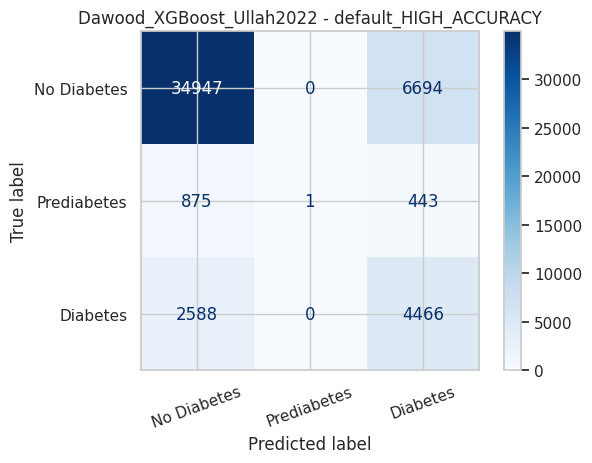

\n Dawood_XGBoost_Ullah2022 safe_threshold
              precision    recall  f1-score   support

 No Diabetes     0.9098    0.8392    0.8731     41641
 Prediabetes     1.0000    0.0008    0.0015      1319
    Diabetes     0.3849    0.6331    0.4787      7054

    accuracy                         0.7881     50014
   macro avg     0.7649    0.4910    0.4511     50014
weighted avg     0.8382    0.7881    0.7945     50014



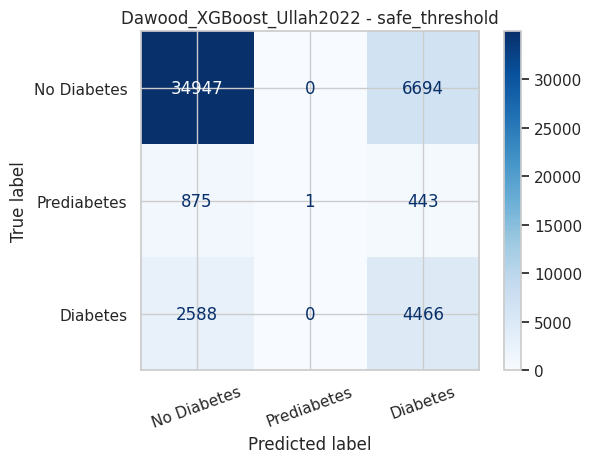

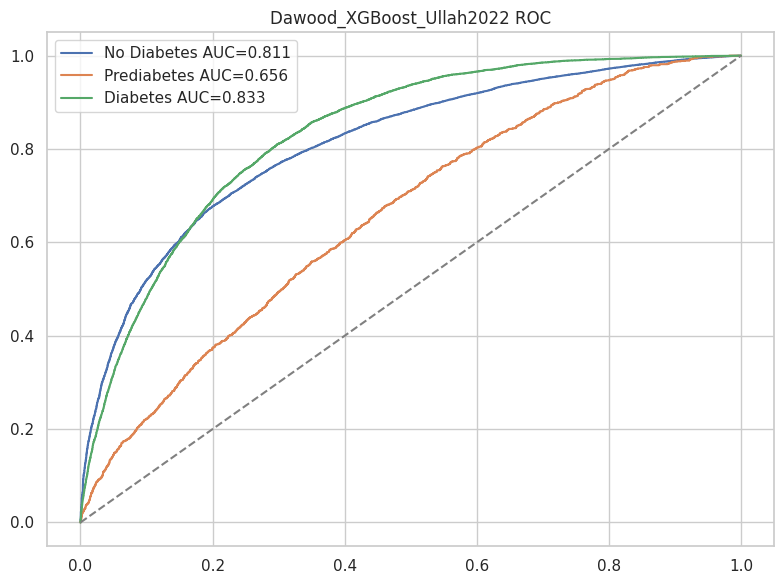

In [4]:
metrics, threshold = show_results(model, MODEL_NAME, threshold_tuning=True)
plot_roc_pr(model, MODEL_NAME)

## XAI: PFI, PDP, ICE, SHAP, LIME, Surrogate

,feature,importance
0,GenHlth,0.046115
1,HighBP,0.030631
3,BMI_x_Age,0.025655
15,BMI,0.007951
7,Sex,0.006567
18,TimeSinceCheckup,0.006362
14,MetS_score,0.005172
5,HighChol,0.004078
4,CV_burden_weighted,0.002711
13,HvyAlcoholConsump,0.002694


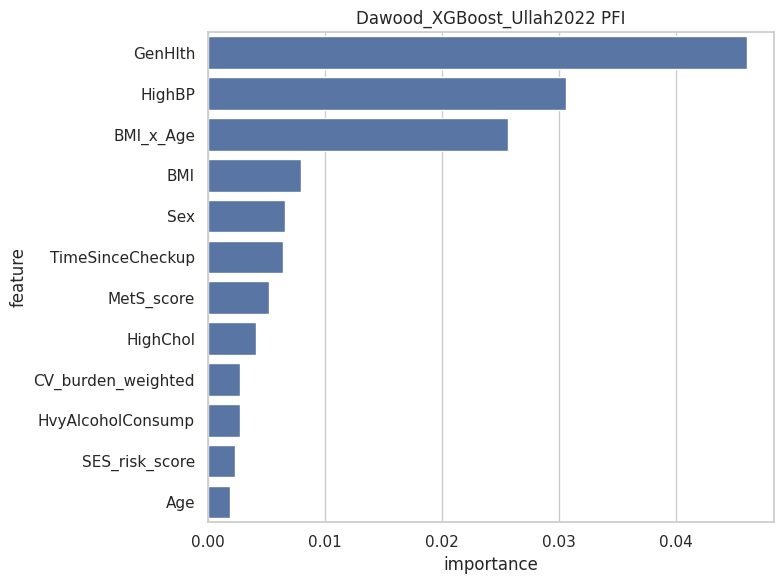

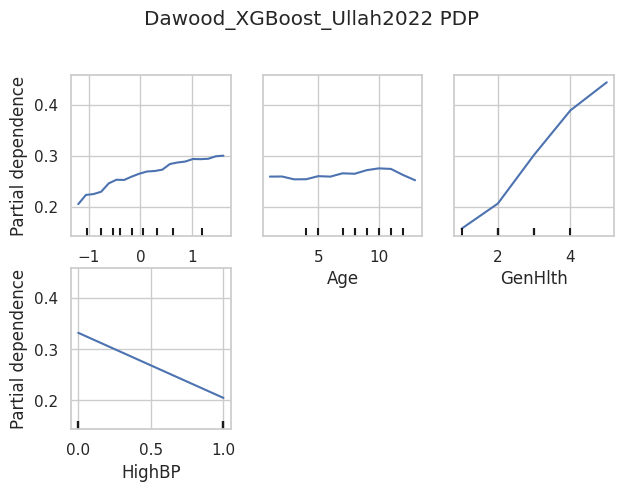

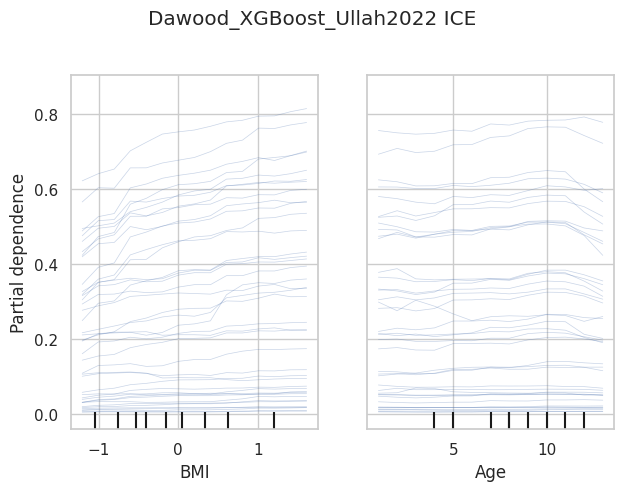

  0%|          | 0/40 [00:00<?, ?it/s]

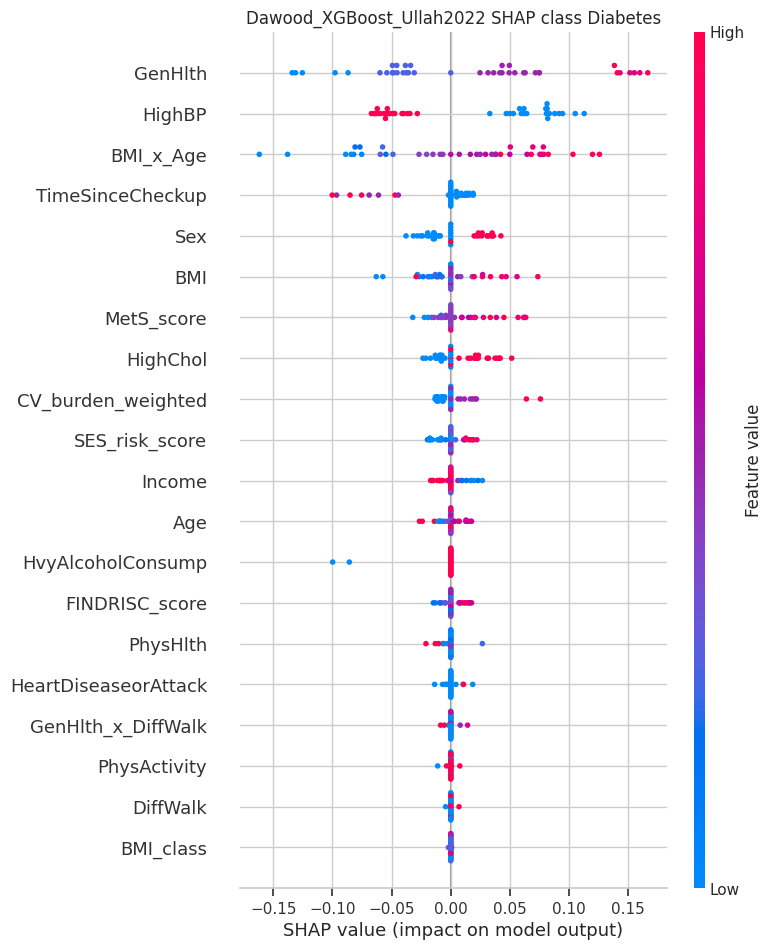

Surrogate fidelity: 0.87645459271404


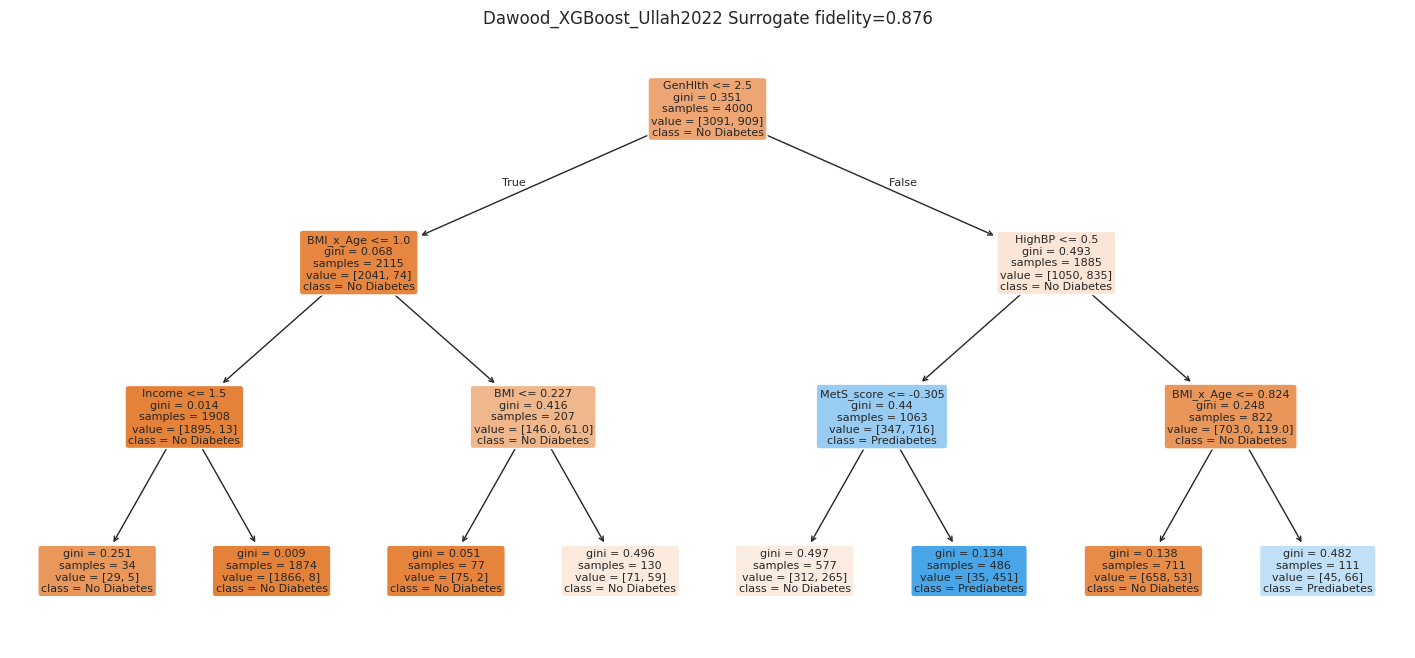

In [5]:
run_xai(model, MODEL_NAME)